<a href="https://colab.research.google.com/github/snehasawant054-design/CSL701-CE-43_Machine-Learning-Lab./blob/main/Experiments/Experiment6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Sneha Baburao Sawant
Roll No: CE-43
Batch: CE-03

Aim

To implement Support Vector Machine (SVM) for classification of the Iris dataset and visualize its decision boundary and compare it with a normal linear classification boundary.

## Objectives

1. To understand the concept of Support Vector Machine.
2. To implement SVM using Python.
3. To visualize the SVM decision boundary.
4. To identify the support vectors.
5. To compare the SVM boundary with a normal linear classification boundary.
6. To evaluate the performance of the classifiers.

# Relevant Theory

### Support Vector Machine

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification.

SVM finds a decision boundary that separates different classes while trying to maximize the distance, called the **margin**, between the classes.

The points closest to the decision boundary are called **support vectors**.

For a linear SVM, the decision boundary can be represented as:

$$
w^T x + b = 0
$$

where:

- $w$ = weight vector
- $x$ = input features
- $b$ = bias


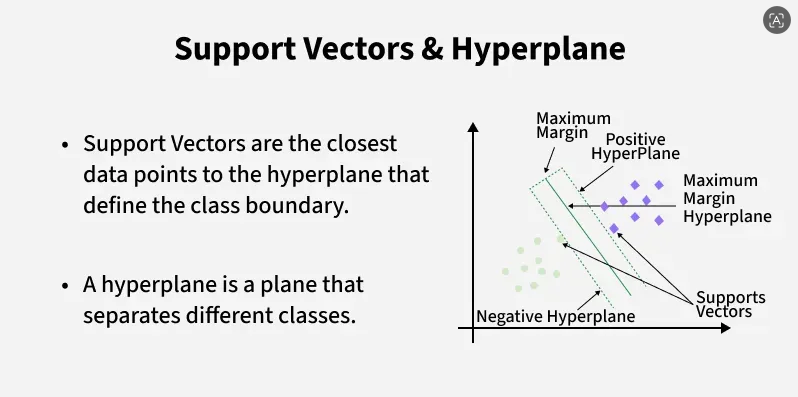
### Kernel

SVM can use different kernels to create decision boundaries.

Common kernels are:

- Linear
- Polynomial
- RBF
- Sigmoid

In this experiment, we mainly use the **Linear SVM** and **RBF SVM**.

---

# Dataset Information

Get the IRIS dataset from Kaggle using below link

https://www.kaggle.com/datasets/uciml/iris

The Iris dataset contains measurements of Iris flowers belonging to three classes:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

The four features are:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

For visualization, we will use:

**Petal Length and Petal Width.**

# Task 1: Import Libraries and Load Dataset

Load the Iris dataset.

---

In [ ]:
import pandas as pd
import numpy as np
import zipfile
import os
from google.colab import files

# Upload ZIP file
uploaded = files.upload()

# Get ZIP file name
zip_file = list(uploaded.keys())[0]

# Extract ZIP file
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("dataset")

# Display extracted files
print("Files inside ZIP:")
print(os.listdir("dataset"))

# Read Iris.csv
df = pd.read_csv("dataset/Iris.csv")

# Display dataset information
print("\nDataset uploaded successfully!")
print("Dataset Shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

Saving archive (7).zip to archive (7) (1).zip
Files inside ZIP:
['Iris.csv', 'database.sqlite']

Dataset uploaded successfully!
Dataset Shape: (150, 6)

First 5 rows:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


# Task 2: Explore the Dataset

In [ ]:
# Display dataset information

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nFirst 5 Rows:")
display(df.head())

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape:
(150, 6)

Column Names:
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

Missing Values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

First 5 Rows:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa



Statistical Summary:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


# Task 3: Select Features and Target

Remove the `Id` column.

Select Remaining Features

In [ ]:
# Remove unnecessary Id column
df = df.drop('Id', axis=1)

# Separate features and target
X = df.drop('Species', axis=1)
y = df['Species']

print("Features (X):")
display(X.head())

print("\nTarget (y):")
display(y.head())

print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget classes:")
print(y.unique())

Features (X):


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



Target (y):


,Species
0,Iris-setosa
1,Iris-setosa
2,Iris-setosa
3,Iris-setosa
4,Iris-setosa



Feature columns:
['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

Target classes:
['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


# Task 4: Split and Scale the Data

Divide the dataset into training and testing sets.

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder
label_encoder = LabelEncoder()

# Convert species names into numbers
y = label_encoder.fit_transform(y)

# Display encoded values
print("Encoded Target:")
print(y)

# Display mapping
print("\nClass Mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(i, "=", class_name)

Encoded Target:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]

Class Mapping:
0 = Iris-setosa
1 = Iris-versicolor
2 = Iris-virginica


# Task 5: Implement Linear SVM

Create an SVM model using a **linear kernel**.

Make predictions.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Create StandardScaler
scaler = StandardScaler()

# Fit scaler on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

# Display shapes
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

print("\nTraining target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training data shape: (120, 4)
Testing data shape: (30, 4)

Training target shape: (120,)
Testing target shape: (30,)


# Task 6: Evaluate SVM

### Calculate Accuracy

Calculate the accuracy of the SVM model.

### Confusion Matrix

Generate the confusion matrix to evaluate the classification results.

### Classification Report

Generate the classification report containing:

- Precision
- Recall
- F1-Score
- Support

---


In [ ]:
from sklearn.svm import SVC

# Create Linear SVM model
svm_model = SVC(kernel='linear', random_state=42)

# Train the model
svm_model.fit(X_train_scaled, y_train)

print("Linear SVM model trained successfully!")

Linear SVM model trained successfully!


# Task 7: Visualize SVM Decision Boundary

For visualization, we use only two features:

- Petal Length
- Petal Width

### Create the 2-D Dataset

Select **Petal Length** and **Petal Width** as the input features.

### Split the Data

Divide the 2-D dataset into training and testing sets.

### Scale the Data

Standardize the selected features before training the SVM model.

### Train SVM

Train an SVM classifier using a **linear kernel**.

### Plot Decision Boundary

Visualize the SVM decision boundary along with the data points.

---

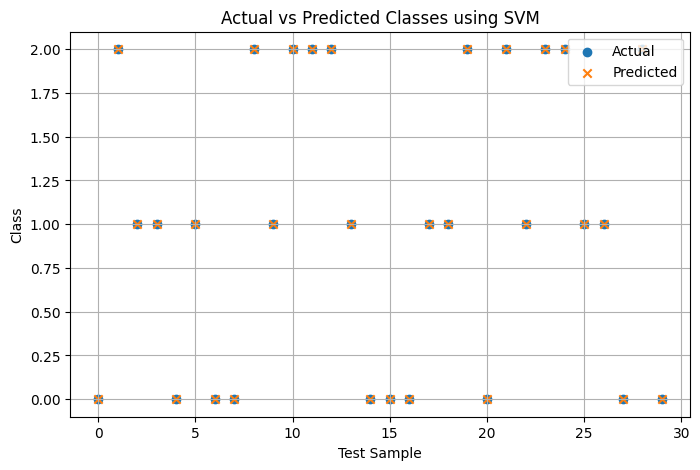

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(range(len(y_test)), y_test, label="Actual", marker='o')
plt.scatter(range(len(y_pred)), y_pred, label="Predicted", marker='x')

plt.xlabel("Test Sample")
plt.ylabel("Class")
plt.title("Actual vs Predicted Classes using SVM")
plt.legend()
plt.grid(True)
plt.show()

# Task 8: Normal Linear Classification Boundary

For comparison, we use **Logistic Regression** as a normal linear classifier.

Train a Logistic Regression model using the same two features and visualize its decision boundary.

---

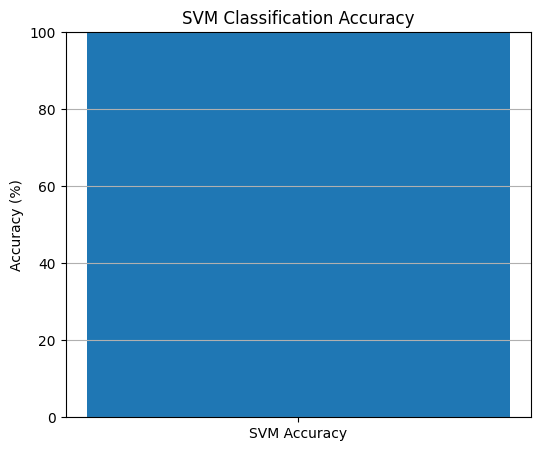

SVM Accuracy: 100.0 %


In [16]:
import matplotlib.pyplot as plt

accuracy = accuracy_score(y_test, y_pred)

plt.figure(figsize=(6,5))

plt.bar(["SVM Accuracy"], [accuracy * 100])

plt.ylabel("Accuracy (%)")
plt.title("SVM Classification Accuracy")
plt.ylim(0, 100)
plt.grid(axis='y')

plt.show()

print("SVM Accuracy:", accuracy * 100, "%")

# Task 9: Compare SVM and Normal Boundary

Plot both the **SVM** and **Logistic Regression** decision boundaries on the same graph.

Compare how the two classifiers separate the different classes.

---

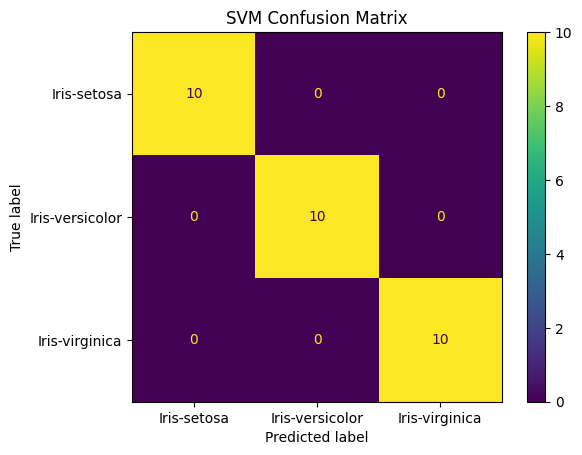

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot()
plt.title("SVM Confusion Matrix")
plt.show()

# Task 10: Compare Performance

Compare the performance of the **Linear SVM** and **Logistic Regression** using:

- Accuracy
- Confusion Matrix
- Classification Report

---

In [ ]:
support_vectors = svm_model.support_vectors_

print("Number of Support Vectors:")
print(len(support_vectors))

print("\nSupport Vectors:")
print(support_vectors)

Number of Support Vectors:
23

Support Vectors:
[[-1.60215265 -1.67677431 -1.40385252 -1.18869941]
 [-0.88566202  0.57644985 -1.17658466 -0.92576129]
 [ 1.14439475 -0.55016223  0.58474127  0.25746024]
 [ 0.18907392 -0.32483982  0.41429037  0.3889293 ]
 [ 0.54731923 -1.22612948  0.64155823  0.3889293 ]
 [ 0.06965881  0.35112743  0.58474127  0.78333648]
 [ 0.18907392 -0.77548465  0.75519216  0.52039836]
 [-0.2885865  -0.0995174   0.41429037  0.3889293 ]
 [ 0.78614944 -0.55016223  0.47110734  0.3889293 ]
 [ 0.18907392  0.80177226  0.41429037  0.52039836]
 [ 0.42790412 -1.90209672  0.41429037  0.3889293 ]
 [-0.88566202 -1.22612948 -0.43796411 -0.13694694]
 [ 1.26380985  0.12580502  0.64155823  0.3889293 ]
 [-1.12449223 -1.22612948  0.41429037  0.65186742]
 [ 0.54731923 -1.22612948  0.6983752   0.91480554]
 [ 0.54731923 -0.55016223  0.75519216  0.3889293 ]
 [ 0.66673433  0.12580502  0.98246003  0.78333648]
 [ 0.06965881 -0.0995174   0.75519216  0.78333648]
 [ 0.18907392 -1.90209672  0.69837

# Conclusion

The experiment successfully demonstrated the implementation of **Support Vector Machine (SVM)** using the Iris dataset. The dataset was preprocessed and standardized before training the model.

A **Linear SVM** was implemented and its decision boundary was visualized along with the support vectors. A normal linear classification boundary using **Logistic Regression** was also visualized for comparison.